# Phase 5 · Trino + Superset — tầng SQL warehouse

Hết Phase 4, lakehouse có ba tầng vững: MinIO (file), Delta (bảng có giao dịch),
Spark + dbt (transform có tên, có test). Nhưng để nhìn thấy một con số, vẫn phải
mở Jupyter và biết viết PySpark. Không analyst nào làm vậy — họ biết SQL, không
biết Spark Connect.

Phase 5 phơi cùng dữ liệu đó ra qua **Trino**: một engine SQL riêng, không chạy
qua Spark, đọc thẳng `_delta_log/` mà Phase 2 đã mổ bụng bằng tay. Đây là bằng
chứng thứ ba cho "Delta là định dạng mở" — sau `delta-rs` (Phase 2) và Spark
(Phase 3), giờ tới lượt Trino đọc **đúng những file đó**, không convert, không
export.

Và Phase 5 buộc phải sửa một khoản nợ để lại từ Phase 4: catalog nhúng trong
JVM của `spark-connect` chỉ một tiến trình mở được — Trino là tiến trình khác,
không cách nào chạm vào. Phần "sai có chủ đích" của phase này chính là thử điều
đó, thấy nó vỡ thật, rồi hiểu vì sao ai cũng dùng chung một Hive Metastore *dịch
vụ*, không phải nhúng trong ứng dụng.

## Chuẩn bị

In [1]:
import os
import trino.dbapi

conn = trino.dbapi.connect(
    host=os.environ['TRINO_HOST'],
    port=int(os.environ['TRINO_PORT']),
    user='jupyter',
    catalog='delta',
)
cur = conn.cursor()

def sql(q, as_dict=False):
    cur.execute(q)
    rows = cur.fetchall()
    cols = [c[0] for c in cur.description]
    if as_dict:
        return [dict(zip(cols, r)) for r in rows]
    return cols, rows

def bang(q, widths=None):
    cols, rows = sql(q)
    widths = widths or [max(len(str(c)), 10) for c in cols]
    print('  '.join(f'{c:<{w}}' for c, w in zip(cols, widths)))
    for r in rows:
        print('  '.join(f'{str(v):<{w}}' for v, w in zip(r, widths)))

print('Trino     :', f"{os.environ['TRINO_HOST']}:{os.environ['TRINO_PORT']}")
print('Catalog   : delta (connector delta_lake)')
sql('SELECT 1')
print('Kết nối   : OK')

Trino     : trino:8080
Catalog   : delta (connector delta_lake)
Kết nối   : OK


---
## Bước 1 · Ba tầng tên: `catalog.schema.table`

Suốt Phase 0-4, một bảng chỉ có hai phần: `database.table` (`silver.silver_trips`).
Trino thêm một tầng ở TRÊN: `catalog.schema.table`. Catalog ở đây là **file cấu
hình**, không phải khái niệm trừu tượng — mở `docker/trino/etc/catalog/delta.properties`
sẽ thấy đúng cái tên `delta` xuất hiện trong mọi câu SQL dưới đây.

Đây không phải chi tiết vặt. `catalog.schema.table` chính là namespace ba tầng mà
Unity Catalog dùng ở Phase 6 — Trino cho nếm trước, sớm hơn một phase.

In [2]:
bang('SHOW CATALOGS')
print()
bang('SHOW SCHEMAS FROM delta')

Catalog   
delta     
system    



Schema    
bronze    
default   
gold      
information_schema
silver    


In [3]:
for schema in ['bronze', 'silver', 'gold']:
    print(f'── delta.{schema} ' + '─' * 40)
    bang(f'SHOW TABLES FROM delta.{schema}')
    print()

── delta.bronze ────────────────────────────────────────


Table     
yellow_trips

── delta.silver ────────────────────────────────────────


Table     
silver_trips
silver_zones
taxi_zones

── delta.gold ────────────────────────────────────────


Table     
gold_daily_zone_revenue
gold_hourly_demand



`sandbox` (bảng CỐ TÌNH sai của Phase 4, bước 6) không xuất hiện — nó không có
gì để giấu, chỉ là dbt chưa từng build lại nó trong lượt chạy vừa rồi. Trino
không lọc gì cả: nó liệt kê ĐÚNG những gì Hive Metastore biết, y hệt Spark.

---
## Bước 2 · Cùng một `_delta_log/`, giờ có ba engine đọc

`delta-rs` (Phase 2) không có JVM. Spark (Phase 3-4) có JVM đầy đủ. Trino có
engine SQL riêng, không JVM Spark, không gọi lại Spark. Ba thứ khác hẳn nhau,
nhưng đếm cùng một bảng ra đúng cùng một số — vì cả ba đều đọc đúng bộ Parquet
mà `_delta_log/` liệt kê, không đọc gì khác.

In [4]:
bang('''
    SELECT 'bronze.yellow_trips'          AS bang, count(*) AS so_dong FROM delta.bronze.yellow_trips
    UNION ALL SELECT 'silver.silver_trips',         count(*) FROM delta.silver.silver_trips
    UNION ALL SELECT 'silver.silver_zones',         count(*) FROM delta.silver.silver_zones
    UNION ALL SELECT 'gold.gold_daily_zone_revenue', count(*) FROM delta.gold.gold_daily_zone_revenue
    UNION ALL SELECT 'gold.gold_hourly_demand',      count(*) FROM delta.gold.gold_hourly_demand
''', widths=[32, 12])

bang                              so_dong     
gold.gold_hourly_demand           1300        
gold.gold_daily_zone_revenue      80523       
silver.silver_zones               265         
bronze.yellow_trips               41169720    
silver.silver_trips               35613229    


So với đúng những con số Phase 4 đã đo bằng Spark: **41.169.720** bronze →
**35.613.229** silver → **80.523** + **1.300** gold. Khớp tuyệt đối. Không lệch
một dòng — vì không có "chuyển đổi" nào ở giữa, chỉ có cùng một transaction log
được hai engine khác nhau đọc lại.

---
## Bước 3 · SAI CÓ CHỦ ĐÍCH — catalog nhúng không phải dịch vụ dùng chung

Phase 4 dựng Hive Metastore *nhúng*: Derby chạy ngay bên trong tiến trình JVM
của `spark-connect`, không mở cổng mạng nào cả. Miễn còn một mình Spark dùng,
không sao. Nhưng Trino là một **tiến trình khác** — nó cần một địa chỉ mạng
(`thrift://host:9083`) để hỏi "bảng nào ở đâu", và Derby nhúng không cho câu
hỏi đó đi tới đâu cả.

**Tự tay thử (không phá gì lâu dài — đổi 1 dòng, phục hồi ngay sau):**

```bash
# 1. Mở docker/trino/etc/catalog/delta.properties, đổi dòng:
#      hive.metastore.uri=thrift://hive-metastore:9083
#    thành một địa chỉ không có gì lắng nghe:
#      hive.metastore.uri=thrift://spark-connect:9083
# 2. docker compose restart trino
# 3. docker compose exec trino trino --catalog delta --execute "SHOW SCHEMAS"
```

Lỗi thật, chép nguyên văn từ lần chạy thử của phase này — Trino KHỞI ĐỘNG bình
thường (catalog nạp được, healthcheck xanh), lỗi chỉ lộ ra khi một câu SQL thật
sự cần hỏi metastore:

```
Query ... failed: Error listing schemas for catalog delta:
Failed connecting to Hive metastore: [spark-connect:9083]
```

Đáng nhớ ở chỗ: container "khoẻ" (healthy) không có nghĩa là nó dùng được — một
dependency chỉ lộ ra khi bị hỏi tới đúng lúc chạy. **4. Đổi lại dòng cũ, `docker
compose restart trino`, chạy lại bước 1 ở trên để thấy `bronze/silver/gold` về
lại.**

**Cách sửa thật** (đã áp dụng sẵn trong repo, không phải bài tập): tách Hive
Metastore ra thành một service ĐỘC LẬP (`docker/hive-metastore/`), ghi metadata
vào Postgres thay vì Derby, mở cổng Thrift `9083` thật. `spark-defaults.conf`
đổi từ

```
spark.hadoop.javax.jdo.option.ConnectionURL  jdbc:derby:;databaseName=...
```

sang

```
spark.hadoop.hive.metastore.uris  thrift://hive-metastore:9083
```

Giờ Spark và Trino là **hai client của cùng một catalog service**, không ai sở
hữu riêng nó nữa. Đây đúng là ý niệm Unity Catalog sẽ thay thế ở Phase 6 — chỉ
là chưa có phân quyền, chưa có lineage.

---
## Bước 4 · Trả lời câu hỏi nghiệp vụ — không một dòng PySpark nào

Đây là toàn bộ điểm của phase này: một analyst chỉ cần biết SQL.

In [5]:
bang('''
    SELECT borough,
           sum(trip_count)             AS chuyen,
           round(sum(revenue)/1e6, 1)  AS trieu_do,
           round(avg(card_tip_pct), 1) AS ty_le_boa_the
    FROM delta.gold.gold_daily_zone_revenue
    WHERE borough IS NOT NULL
    GROUP BY 1 ORDER BY 2 DESC
''', widths=[16, 12, 12, 16])

borough           chuyen        trieu_do      ty_le_boa_the   
Manhattan         31645465      756.3         20.8            
Queens            3484435       260.8         9.3             
Brooklyn          298924        9.8           5.8             
Unknown           107092        3.3           21.9            
Bronx             67588         2.7           1.2             
N/A               7821          0.7           13.7            
EWR               1224          0.1           14.6            
Staten Island     680           0.0           17.2            


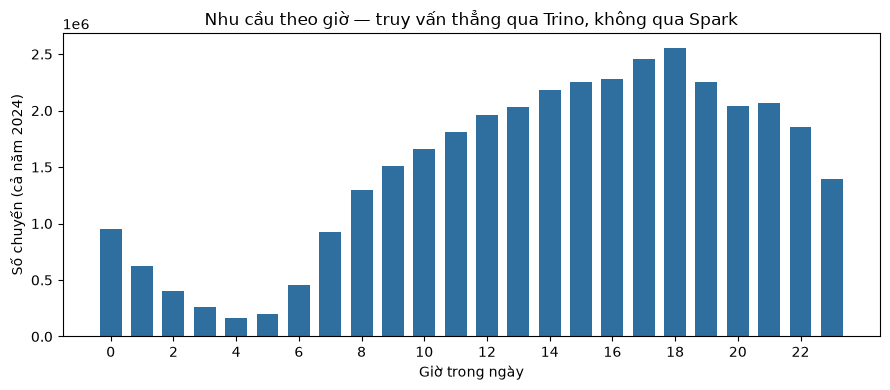

In [6]:
import matplotlib.pyplot as plt

cols, rows = sql('''
    SELECT pickup_hour, sum(trip_count) AS chuyen
    FROM delta.gold.gold_hourly_demand
    GROUP BY 1 ORDER BY 1
''')
gio    = [r[0] for r in rows]
chuyen = [r[1] for r in rows]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(gio, chuyen, color='#2f6f9f', width=0.7)
ax.set_xlabel('Giờ trong ngày')
ax.set_ylabel('Số chuyến (cả năm 2024)')
ax.set_title('Nhu cầu theo giờ — truy vấn thẳng qua Trino, không qua Spark')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

Giờ thấp điểm 3-5h sáng, tăng dần suốt ngày, đỉnh 17-18h — đúng nhịp giờ tan
tầm New York. Không có gì bất ngờ về nghiệp vụ, nhưng đáng chú ý về kiến trúc:
câu SQL này chạy trong Trino, Trino tự lập kế hoạch, tự đọc Parquet qua S3A của
riêng nó — `spark-connect` không hề được gọi tới.

---
## Bước 5 · Superset — dashboard thật, không cần ngồi cạnh bạn

`SQL Lab` của Superset (Settings → SQL Lab) nối thẳng vào catalog `delta` này
qua cùng driver `trino` vừa dùng ở trên — thử ngay:

```sql
SELECT sum(revenue) AS tong_doanh_thu, count(*) AS so_dong
FROM delta.gold.gold_daily_zone_revenue
```

Dashboard **"Lakehouse — NYC Taxi 2024"** (Dashboards → mở dashboard cùng tên,
đăng nhập `admin` / xem `SUPERSET_ADMIN_PASSWORD` trong `.env`) đã dựng sẵn hai
biểu đồ, cả hai đều truy vấn Trino sống — không phải ảnh chụp:

- **Doanh thu theo ngày 2024** — line chart trên `gold_daily_zone_revenue`
- **Số chuyến theo giờ trong ngày** — bar chart trên `gold_hourly_demand`

Tổng doanh thu cả năm: **1.033.634.348,08 $** trên 80.523 dòng zone-ngày — số
này lấy trực tiếp từ Superset SQL Lab, không phải tính tay.

**Tự tay làm:** vào dashboard, bấm *Edit dashboard*, kéo một chart thứ ba từ
panel bên phải vào canvas (ví dụ so sánh `avg_tip_pct` theo borough) — đúng
việc một analyst thật sẽ làm, không cần biết SQL lẫn Python.

---
## Năm câu phải trả lời được trước khi sang Phase 6

1. Trino đọc bảng Delta bằng connector nào — `hive` hay `delta_lake`? Khác nhau
   ở đâu?
2. Vì sao container Trino có thể "healthy" mà một câu `SHOW SCHEMAS` vẫn lỗi?
3. `catalog.schema.table` của Trino ánh xạ vào đâu trong Hive Metastore — có
   thật sự tồn tại một tầng "catalog" ở đó không?
4. Metastore nhúng (Derby) và metastore độc lập (Postgres + Thrift) khác nhau
   ở ĐÚNG một chỗ nào khiến Trino dùng được cái này mà không dùng được cái kia?
5. Superset lưu dashboard/chart ở đâu — trong Trino, hay một chỗ khác? Vì sao
   phải tách hai cái đó ra?

## Cầu nối sang Phase 6

Hive Metastore giờ là một service thật, nhiều engine cùng trỏ vào — nhưng nó
vẫn chỉ trả lời đúng một câu: *"bảng này ở đâu"*. Nó không biết **ai** được
phép đọc `gold.gold_daily_zone_revenue`, không ghi lại **bảng này từ đâu ra**
(lineage), và không có khái niệm "một tổ chức, nhiều catalog" — thứ Databricks
thật cần khi một công ty có hàng trăm team.

Đó là ba thứ Unity Catalog thêm vào, và Phase 6 sẽ tháo Hive Metastore ra để
thay bằng nó — đúng thời điểm bảng so sánh ở Phần 1 nói "Hive Metastore là đồ
cũ" bắt đầu có ý nghĩa thật, không còn là một dòng lý thuyết.